# 🚗 Auto Insurance Fraud Detection
## Phase 3 Classification Project

---

### Business Problem

**Stakeholder:** The Claims Investigation Unit of a mid-size auto insurance company.

**Problem Statement:**  
Insurance fraud costs the U.S. industry an estimated **\$40 billion per year**, and those costs are passed on to honest policyholders through higher premiums. The Claims Investigation Unit needs a reliable way to flag potentially fraudulent claims **before** paying them out — so investigators can focus their limited time on the highest-risk cases.

**Our Goal:**  
Build a machine learning classification model that predicts whether a given claim is fraudulent (`fraud_reported = Y`) or legitimate (`fraud_reported = N`), using policyholder demographics, incident details, and claim financials.

---

### Why This is a Classification Problem

Our target variable, `fraud_reported`, is a **category** — either `Y` (fraud) or `N` (no fraud). It is not a number we are trying to predict on a continuous scale. This makes it a classification task, not regression.

---

### Metric Justification

| Metric | Why it matters here |
|--------|---------------------|
| **Recall** | Missing a fraudulent claim (False Negative) means paying out money the company should not. This is the most costly error. |
| **Precision** | Flagging too many legitimate claims (False Positive) wastes investigator time and may upset honest customers. |
| **F1-Score** | Balances Recall and Precision — our primary tuning metric. |
| **ROC-AUC** | Measures overall discriminatory power across all thresholds. |

> **Primary metric: F1-Score (with emphasis on Recall)**

---

### Project Roadmap

1. Setup & Imports  
2. Data Loading & Initial Inspection  
3. Exploratory Data Analysis (EDA)  
4. Feature Engineering & Preprocessing  
5. Model 1 — Baseline Logistic Regression  
6. Model 2 — Logistic Regression with Tuned Hyperparameters  
7. Model 3 — Decision Tree Classifier  
8. Model 4 — Random Forest (Advanced)  
9. Final Model Discussion & Recommendations

## 1. Setup & Imports

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    ConfusionMatrixDisplay, RocCurveDisplay
)
import warnings
warnings.filterwarnings('ignore')

# ── Plot styling ─────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

COLOR_FRAUD  = '#E53935'   # red
COLOR_LEGIT  = '#1E88E5'   # blue
COLOR_ACCENT = '#43A047'   # green

print("All libraries imported successfully!")

All libraries imported successfully!


---
## 2. Data Loading & Initial Inspection

We load the auto insurance claims dataset, which contains **1,000 claims** across **39 features** covering policyholder demographics, incident circumstances, and financial claim details. The target variable is `fraud_reported`.

> **Note on data quality:** Several columns use `'?'` to denote missing values — a common pattern in real insurance datasets. We will treat these as `NaN` during preprocessing.

In [15]:
# ── Load data ────────────────────────────────────────────────────
df = pd.read_csv('Data/insurance_claims.csv')

# Replace '?' with NaN immediately
df.replace('?', np.nan, inplace=True)

print("=" * 60)
print(f"  Dataset shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  Target column : fraud_reported")
print(f"  Fraud cases   : {(df['fraud_reported']=='Y').sum():,}  ({(df['fraud_reported']=='Y').mean()*100:.1f}%)")
print(f"  Legit cases   : {(df['fraud_reported']=='N').sum():,}  ({(df['fraud_reported']=='N').mean()*100:.1f}%)")
print("=" * 60)

df.head()

  Dataset shape : 1,000 rows × 40 columns
  Target column : fraud_reported
  Fraud cases   : 247  (24.7%)
  Legit cases   : 753  (75.3%)


,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,NaN,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [16]:
# ── Data types and missing values ────────────────────────────────
print("Column Overview:")
print("-" * 65)
print(f"{'Column':<35} {'dtype':<12} {'Missing':>8} {'Unique':>8}")
print("-" * 65)
for col in df.columns:
    print(f"  {col:<33} {str(df[col].dtype):<12} {df[col].isnull().sum():>8} {df[col].nunique():>8}")

Column Overview:
-----------------------------------------------------------------
Column                              dtype         Missing   Unique
-----------------------------------------------------------------
  months_as_customer                int64               0      391
  age                               int64               0       46
  policy_number                     int64               0     1000
  policy_bind_date                  str                 0      951
  policy_state                      str                 0        3
  policy_csl                        str                 0        3
  policy_deductable                 int64               0        3
  policy_annual_premium             float64             0      991
  umbrella_limit                    int64               0       11
  insured_zip                       int64               0      995
  insured_sex                       str                 0        2
  insured_education_level           str        

In [17]:
# ── Quick statistical summary of numeric features ────────────────
df.describe().round(2)

,months_as_customer,age,policy_number,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,capital-gains,capital-loss,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_year,_c39
count,1000.00,1000.00,1000.00,1000.00,1000.00,1000.0,1000.00,1000.00,1000.0,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,1000.00,0.0
mean,203.95,38.95,546238.65,1136.00,1256.41,1101000.0,501214.49,25126.10,-26793.7,11.64,1.84,0.99,1.49,52761.94,7433.42,7399.57,37928.95,2005.10,NaN
std,115.11,9.14,257063.01,611.86,244.17,2297406.6,71701.61,27872.19,28104.1,6.95,1.02,0.82,1.11,26401.53,4880.95,4824.73,18886.25,6.02,NaN
min,0.00,19.00,100804.00,500.00,433.33,-1000000.0,430104.00,0.00,-111100.0,0.00,1.00,0.00,0.00,100.00,0.00,0.00,70.00,1995.00,NaN
25%,115.75,32.00,335980.25,500.00,1089.61,0.0,448404.50,0.00,-51500.0,6.00,1.00,0.00,1.00,41812.50,4295.00,4445.00,30292.50,2000.00,NaN
50%,199.50,38.00,533135.00,1000.00,1257.20,0.0,466445.50,0.00,-23250.0,12.00,1.00,1.00,1.00,58055.00,6775.00,6750.00,42100.00,2005.00,NaN
75%,276.25,44.00,759099.75,2000.00,1415.70,0.0,603251.00,51025.00,0.0,17.00,3.00,2.00,2.00,70592.50,11305.00,10885.00,50822.50,2010.00,NaN
max,479.00,64.00,999435.00,2000.00,2047.59,10000000.0,620962.00,100500.00,0.0,23.00,4.00,2.00,3.00,114920.00,21450.00,23670.00,79560.00,2015.00,NaN


---
## 3. Exploratory Data Analysis (EDA)

Before building any model, we need to understand our data. Good EDA answers three key questions:
1. **How imbalanced is our target?** — affects which metrics matter most
2. **What do the numeric features look like, and do fraudulent claims differ?**
3. **Which categorical features are associated with fraud?**

### 3.1 Target Distribution

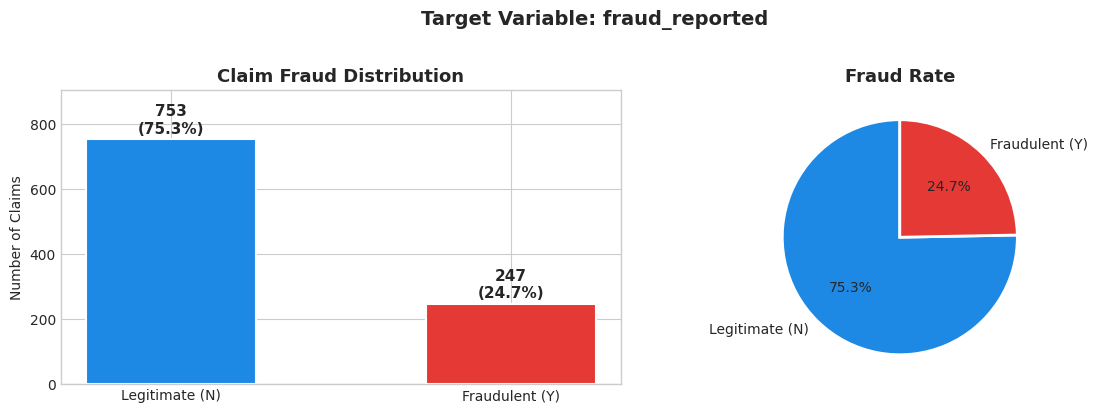


📌 Observation: The dataset is imbalanced — ~75% legitimate, ~25% fraudulent.
   This means accuracy alone is misleading. A model that always predicts 'No Fraud'
   would achieve 75.3% accuracy but catch zero fraudsters!


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# -- Bar chart
counts = df['fraud_reported'].value_counts()
labels = ['Legitimate (N)', 'Fraudulent (Y)']
colors = [COLOR_LEGIT, COLOR_FRAUD]
bars = axes[0].bar(labels, counts.values, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Claim Fraud Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Claims')
axes[0].set_ylim(0, counts.max() * 1.2)
axes[0].tick_params(bottom=False)

# -- Pie chart
axes[1].pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Fraud Rate', fontsize=13, fontweight='bold')

plt.suptitle('Target Variable: fraud_reported', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n📌 Observation: The dataset is imbalanced — ~75% legitimate, ~25% fraudulent.")
print("   This means accuracy alone is misleading. A model that always predicts 'No Fraud'")
print("   would achieve 75.3% accuracy but catch zero fraudsters!")

### 3.2 Numeric Feature Distributions by Fraud Status

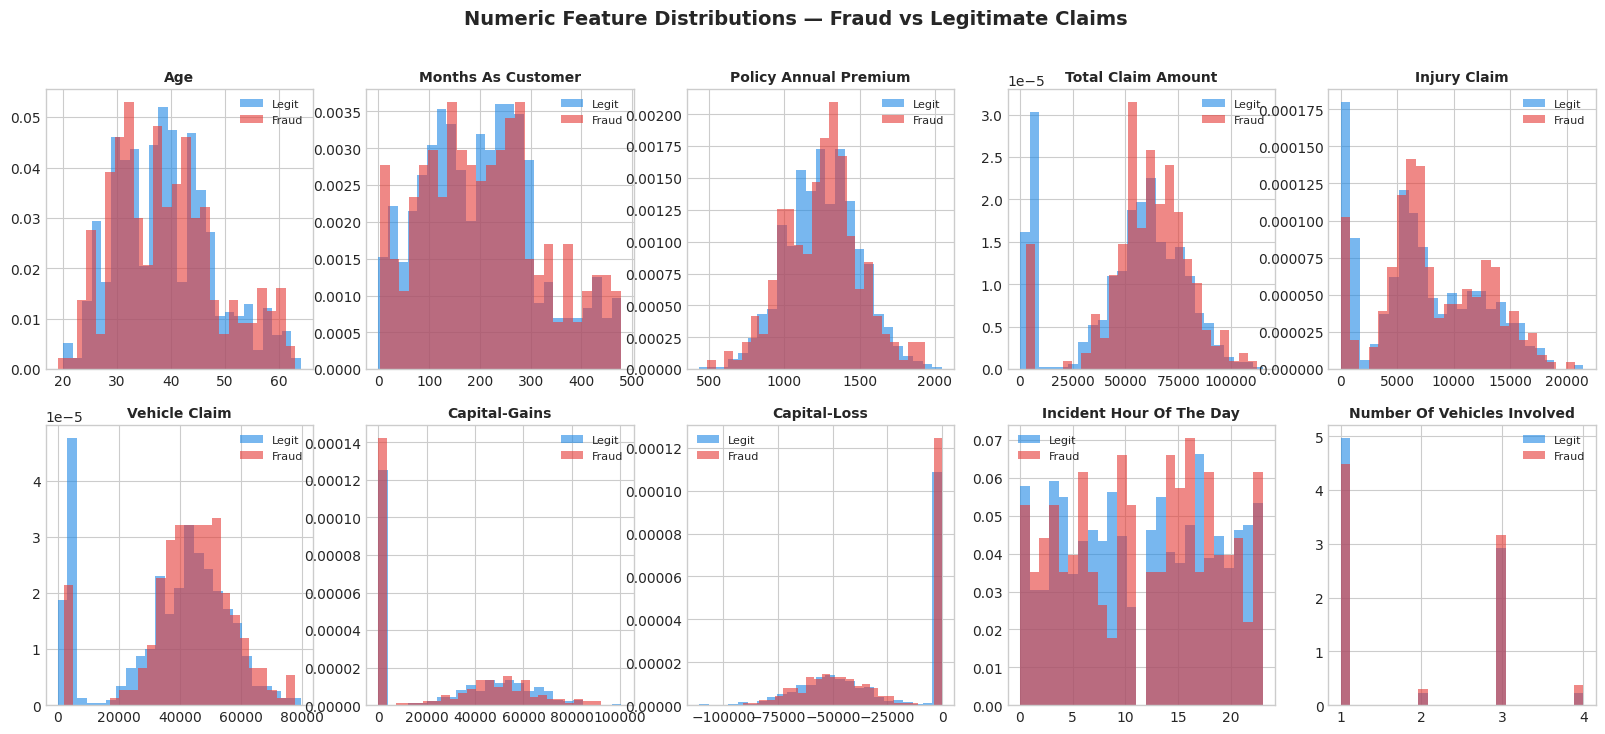

In [24]:
numeric_cols = ['age', 'months_as_customer', 'policy_annual_premium',
                'total_claim_amount', 'injury_claim', 'vehicle_claim',
                'capital-gains', 'capital-loss', 'incident_hour_of_the_day',
                'number_of_vehicles_involved']

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    fraud_vals  = df[df['fraud_reported'] == 'Y'][col].dropna()
    legit_vals  = df[df['fraud_reported'] == 'N'][col].dropna()
    axes[i].hist(legit_vals,  bins=25, alpha=0.6, color=COLOR_LEGIT,  label='Legit',  density=True)
    axes[i].hist(fraud_vals,  bins=25, alpha=0.6, color=COLOR_FRAUD,  label='Fraud',  density=True)
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].legend(fontsize=8)

plt.suptitle('Numeric Feature Distributions — Fraud vs Legitimate Claims', fontsize=14, fontweight='bold')

plt.show()

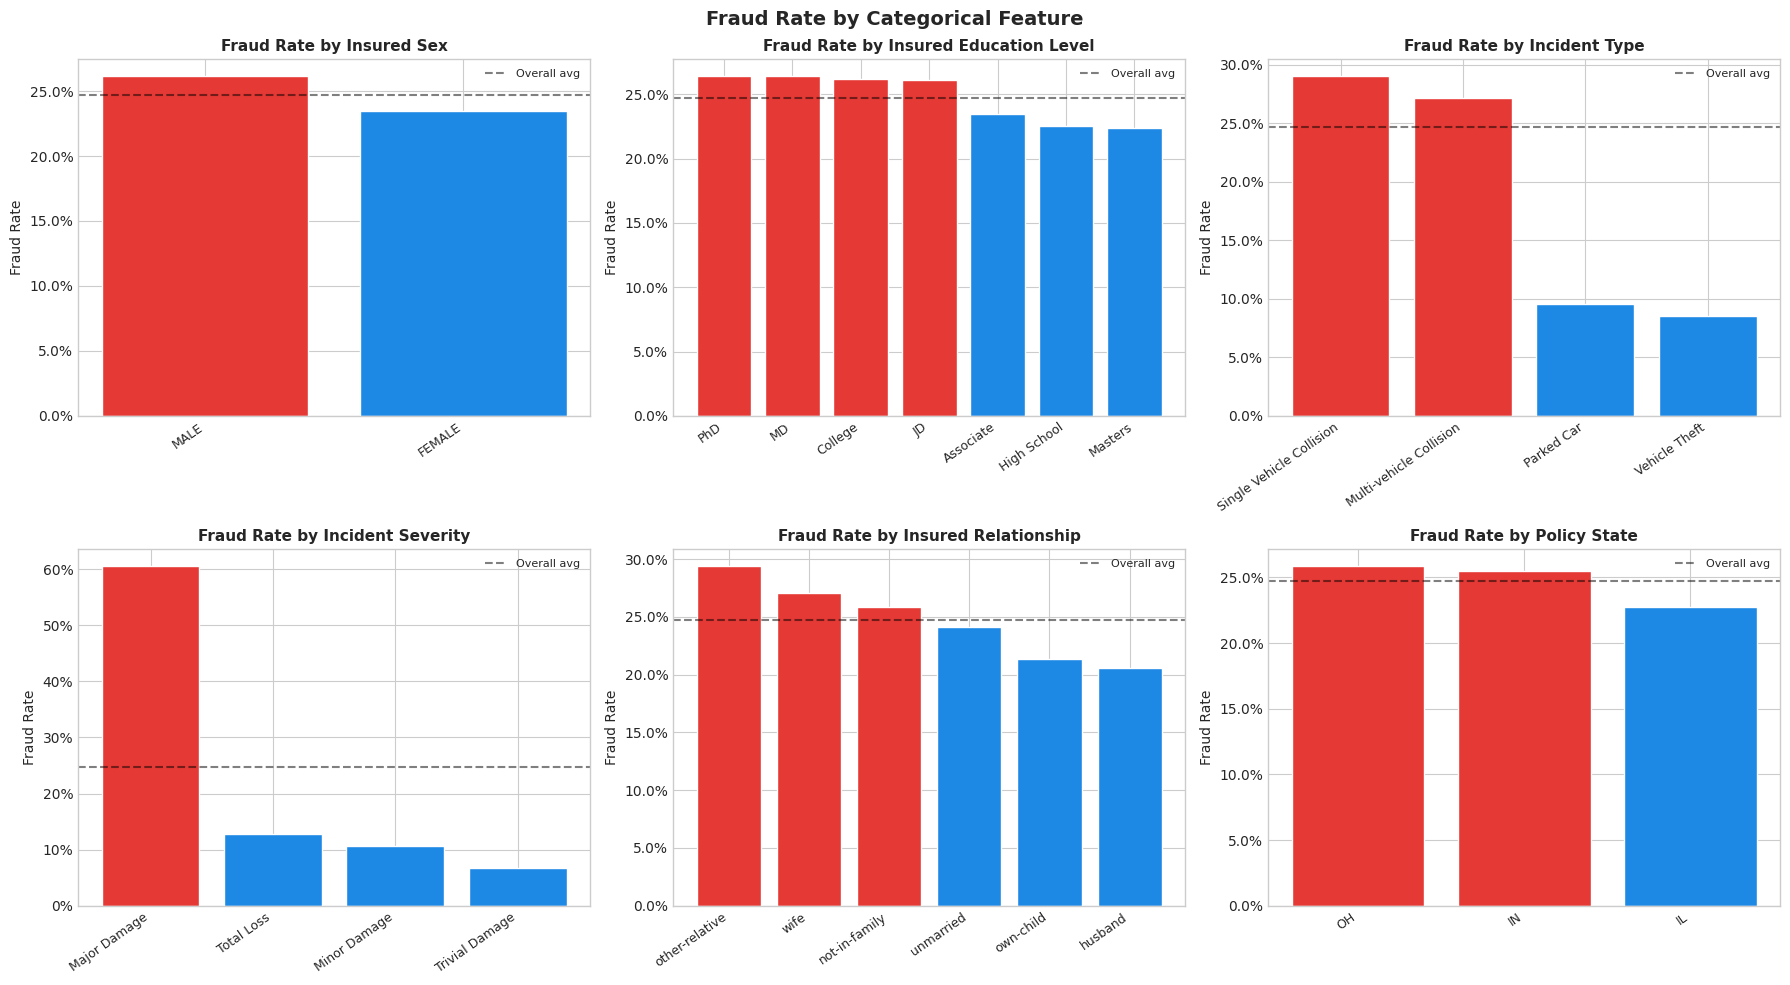

In [26]:
cat_features = ['insured_sex', 'insured_education_level', 'incident_type',
                'incident_severity', 'insured_relationship', 'policy_state']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    fraud_rate = df.groupby(col)['fraud_reported'].apply(lambda x: (x=='Y').mean()).sort_values(ascending=False)
    colors_bar = [COLOR_FRAUD if v > 0.25 else COLOR_LEGIT for v in fraud_rate.values]
    axes[i].bar(range(len(fraud_rate)), fraud_rate.values, color=colors_bar, edgecolor='white')
    axes[i].set_xticks(range(len(fraud_rate)))
    axes[i].set_xticklabels(fraud_rate.index, rotation=35, ha='right', fontsize=9)
    axes[i].set_title(f'Fraud Rate by {col.replace("_"," ").title()}', fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Fraud Rate')
    axes[i].yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    axes[i].axhline(y=(df['fraud_reported']=='Y').mean(), color='black', linestyle='--', alpha=0.5, label='Overall avg')
    axes[i].legend(fontsize=8)

plt.suptitle('Fraud Rate by Categorical Feature', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 3.4 Claim Amount Analysis

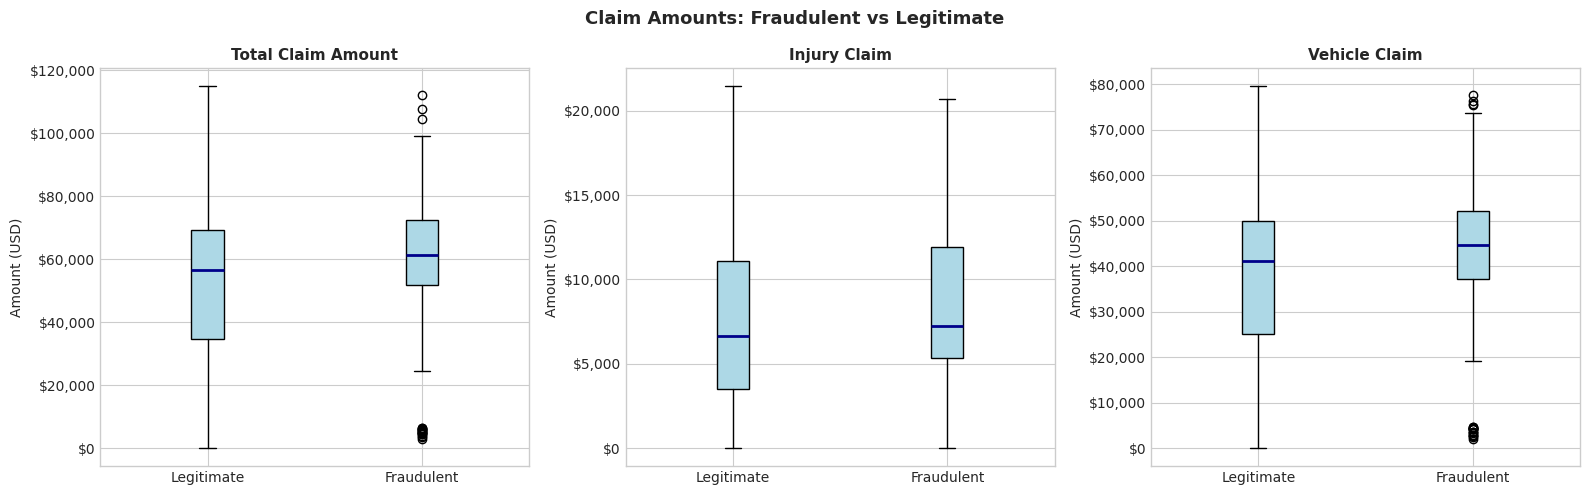


📌 Observation: Fraudulent claims tend to have higher total claim amounts,
   particularly in the vehicle_claim category. This will be an important feature.


In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

claim_cols = ['total_claim_amount', 'injury_claim', 'vehicle_claim']
for i, col in enumerate(claim_cols):
    fraud_vals = df[df['fraud_reported'] == 'Y'][col]
    legit_vals = df[df['fraud_reported'] == 'N'][col]
    axes[i].boxplot([legit_vals, fraud_vals], labels=['Legitimate', 'Fraudulent'],
                    patch_artist=True,
                    boxprops=dict(facecolor='lightblue'),
                    medianprops=dict(color='darkblue', linewidth=2))
    axes[i].set_title(col.replace('_', ' ').title(), fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Amount (USD)')
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.suptitle('Claim Amounts: Fraudulent vs Legitimate', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📌 Observation: Fraudulent claims tend to have higher total claim amounts,")
print("   particularly in the vehicle_claim category. This will be an important feature.")

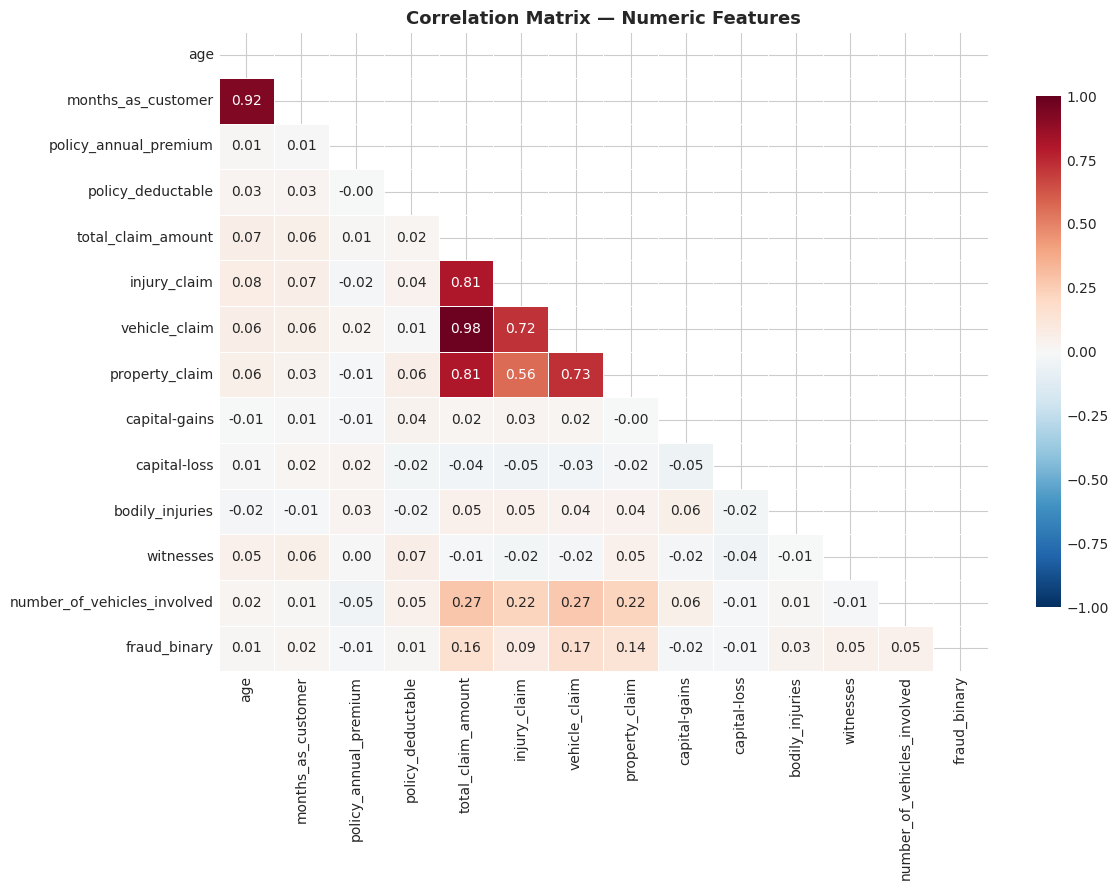


📌 Top correlations with fraud:
   vehicle_claim                       r = 0.170
   total_claim_amount                  r = 0.164
   property_claim                      r = 0.138
   injury_claim                        r = 0.091
   number_of_vehicles_involved         r = 0.052


In [28]:
# Binary-encode target temporarily for correlation
df_corr = df.copy()
df_corr['fraud_binary'] = (df_corr['fraud_reported'] == 'Y').astype(int)
num_cols_corr = ['age', 'months_as_customer', 'policy_annual_premium', 'policy_deductable',
                 'total_claim_amount', 'injury_claim', 'vehicle_claim', 'property_claim',
                 'capital-gains', 'capital-loss', 'bodily_injuries', 'witnesses',
                 'number_of_vehicles_involved', 'fraud_binary']

corr = df_corr[num_cols_corr].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, ax=ax,
            linewidths=0.5, linecolor='white', cbar_kws={'shrink': 0.8})
ax.set_title('Correlation Matrix — Numeric Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📌 Top correlations with fraud:")
fraud_corr = corr['fraud_binary'].drop('fraud_binary').abs().sort_values(ascending=False)
for feat, val in fraud_corr.head(5).items():
    print(f"   {feat:<35} r = {val:.3f}")